In [1]:
import sys

print(sys.executable)

c:\Users\Aiesha\AppData\Local\Python\pythoncore-3.11-64\python.exe


In [4]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [5]:
%pip install --upgrade scikit-learn

  Using cached scikit_learn-1.9.1-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp311-cp311-win_amd64.whl (8.3 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.1


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow: 2.21.0
All libraries imported successfully!


In [8]:
import os

print(os.listdir("../data"))

[]


In [9]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import os

# Load dataset
cancer = load_breast_cancer()

# Create DataFrame
data = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Add target column
data["target"] = cancer.target

# Create data folder if it does not exist
os.makedirs("../data", exist_ok=True)

# Save dataset as CSV
data.to_csv("../data/breast_cancer_dataset.csv", index=False)

print("Dataset saved successfully!")
print("Dataset shape:", data.shape)

Dataset saved successfully!
Dataset shape: (569, 31)


In [10]:
import os

print(os.listdir("../data"))

['breast_cancer_dataset.csv']


In [11]:
data = pd.read_csv("../data/breast_cancer_dataset.csv")

data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [12]:
print("Dataset shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nTarget values:")
print(data["target"].value_counts())

Dataset shape: (569, 31)

Columns:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Missing values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter erro

In [13]:
import pandas as pd

data = pd.read_csv("../data/breast_cancer_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", data.shape)

data.head()

Dataset loaded successfully!
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
X = data.drop("target", axis=1)
y = data["target"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (569, 30)
Target shape: (569,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\Aiesha\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.3736 - loss: 0.7773 - val_accuracy: 0.4835 - val_loss: 0.6428
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5769 - loss: 0.6040 - val_accuracy: 0.8462 - val_loss: 0.5038
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8214 - loss: 0.4908 - val_accuracy: 0.9121 - val_loss: 0.3882
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9231 - loss: 0.3685 - val_accuracy: 0.9341 - val_loss: 0.2961
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9505 - loss: 0.2834 - val_accuracy: 0.9451 - val_loss: 0.2274
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9505 - loss: 0.2195 - val_accuracy: 0.9451 - val_loss: 0.1841
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9670 - loss: 0.1733 - val_accuracy: 0.9451 - val_loss: 0.1565
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9533 - loss: 0.1624 - val_accuracy: 0.9560 - v

In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.10139962285757065
Test accuracy: 0.9561403393745422


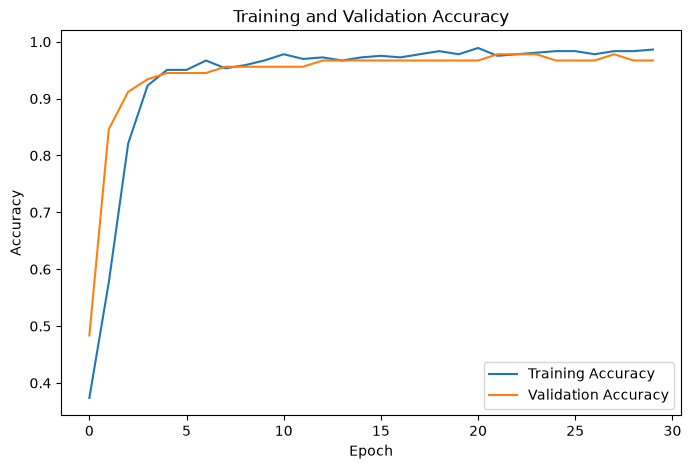

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probability = model.predict(X_test_scaled)

y_pred = (y_pred_probability > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [22]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[41  1]
 [ 4 68]]


# Neural Network Design Choices

## 1. Dataset

The Breast Cancer Wisconsin dataset was used for binary classification.

- Input features: 30 numerical features
- Target column: `target`
- Number of classes: 2
- Task: Binary classification

## 2. Data Preprocessing

The dataset was divided into training and testing sets.

- Training data: 80%
- Testing data: 20%
- Random state: 42
- Stratification: Used to maintain class distribution

StandardScaler was used to standardize the input features. Scaling helps the neural network train more efficiently because the input features are brought to a similar range.

## 3. Neural Network Architecture

The model contains the following layers:

1. Input layer with 30 input features
2. Dense layer with 32 neurons and ReLU activation
3. Dropout layer with a dropout rate of 0.2
4. Dense layer with 16 neurons and ReLU activation
5. Output layer with 1 neuron and sigmoid activation

## 4. Activation Functions

### ReLU

ReLU was selected for the hidden layers because it introduces non-linearity and is computationally efficient.

### Sigmoid

Sigmoid was selected for the output layer because this is a binary classification problem. It produces an output between 0 and 1.

## 5. Loss Function

Binary cross-entropy was used because the task has two possible classes.

## 6. Optimizer

The Adam optimizer was selected because it adapts the learning rate during training and is commonly used for neural-network optimization.

The learning rate was set to `0.001`.

## 7. Dropout

A dropout rate of `0.2` was used to reduce overfitting by randomly disabling some neurons during training.

## 8. Training Configuration

- Epochs: 30
- Batch size: 32
- Validation split: 20%

## 9. Evaluation Metrics

The model was evaluated using:

- Test accuracy
- Classification report
- Precision
- Recall
- F1-score
- Confusion matrix

## 10. Conclusion

The neural network was trained to classify the dataset into two classes. The evaluation results help measure how well the model performs on unseen test data.

In [23]:
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/breast_cancer_neural_network.keras")

print("Model saved successfully!")

Model saved successfully!


In [24]:
import os

print(os.listdir("../models"))

['breast_cancer_neural_network.keras']
